In [ ]:
# PDAN8411 Part 2: Classification and Model Improvement

Student: Boitumelo Malinga  
Student Number: ST10107491  
Dataset: Breast Cancer Wisconsin Diagnostic Dataset  

This notebook develops and evaluates classification models for a cancer-related medical aid use case.
The objective is to classify tumour diagnoses as malignant or benign and evaluate model performance using appropriate classification 
metrics.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [ ]:
## 1. Load Dataset

The Breast Cancer Wisconsin Diagnostic Dataset is loaded from scikit-learn. 
The dataset is suitable for classification because the target variable identifies whether each tumour is malignant or benign.

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["target"] = cancer.target

# Original target meaning:
# 0 = Malignant
# 1 = Benign

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
## 2. Dataset Overview

This section inspects the dataset shape, data types and descriptive statistics to understand the structure of the data before modelling.

In [3]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("Dataset shape:", df.shape)
print("\nDataset information:")
df.info()

df.describe()

Dataset shape: (569, 31)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
## 3. Missing Values

Before training any classification model, the dataset must be checked for missing values because missing data can affect model 
accuracy and reliability.

In [4]:
# ============================================================
# CHECK FOR MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()
missing_values

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [ ]:
## 4. Target Variable Distribution

The diagnosis labels are created to make the class distribution easier to interpret visually.

In [5]:
# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

df["diagnosis_label"] = df["target"].map({
    0: "Malignant",
    1: "Benign"
})

df["diagnosis_label"].value_counts()

diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

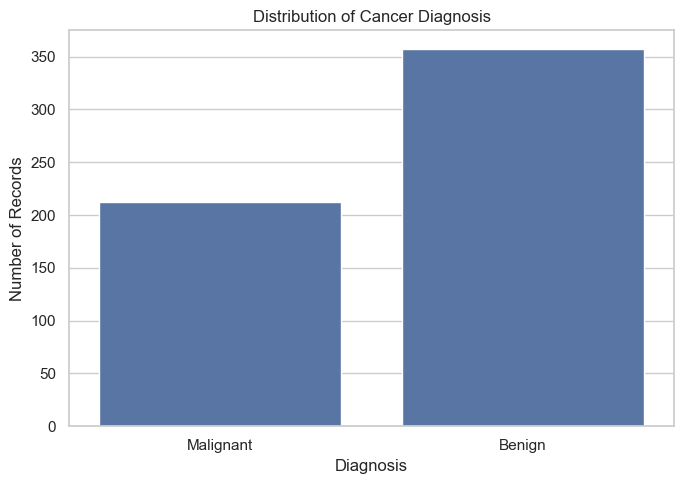

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="diagnosis_label",
    data=df,
    order=["Malignant", "Benign"]
)

plt.title("Distribution of Cancer Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [ ]:
## 5. Correlation Analysis

The correlation heatmap is used to identify relationships between numerical features.
This helps show whether the dataset contains meaningful predictive patterns for classification.

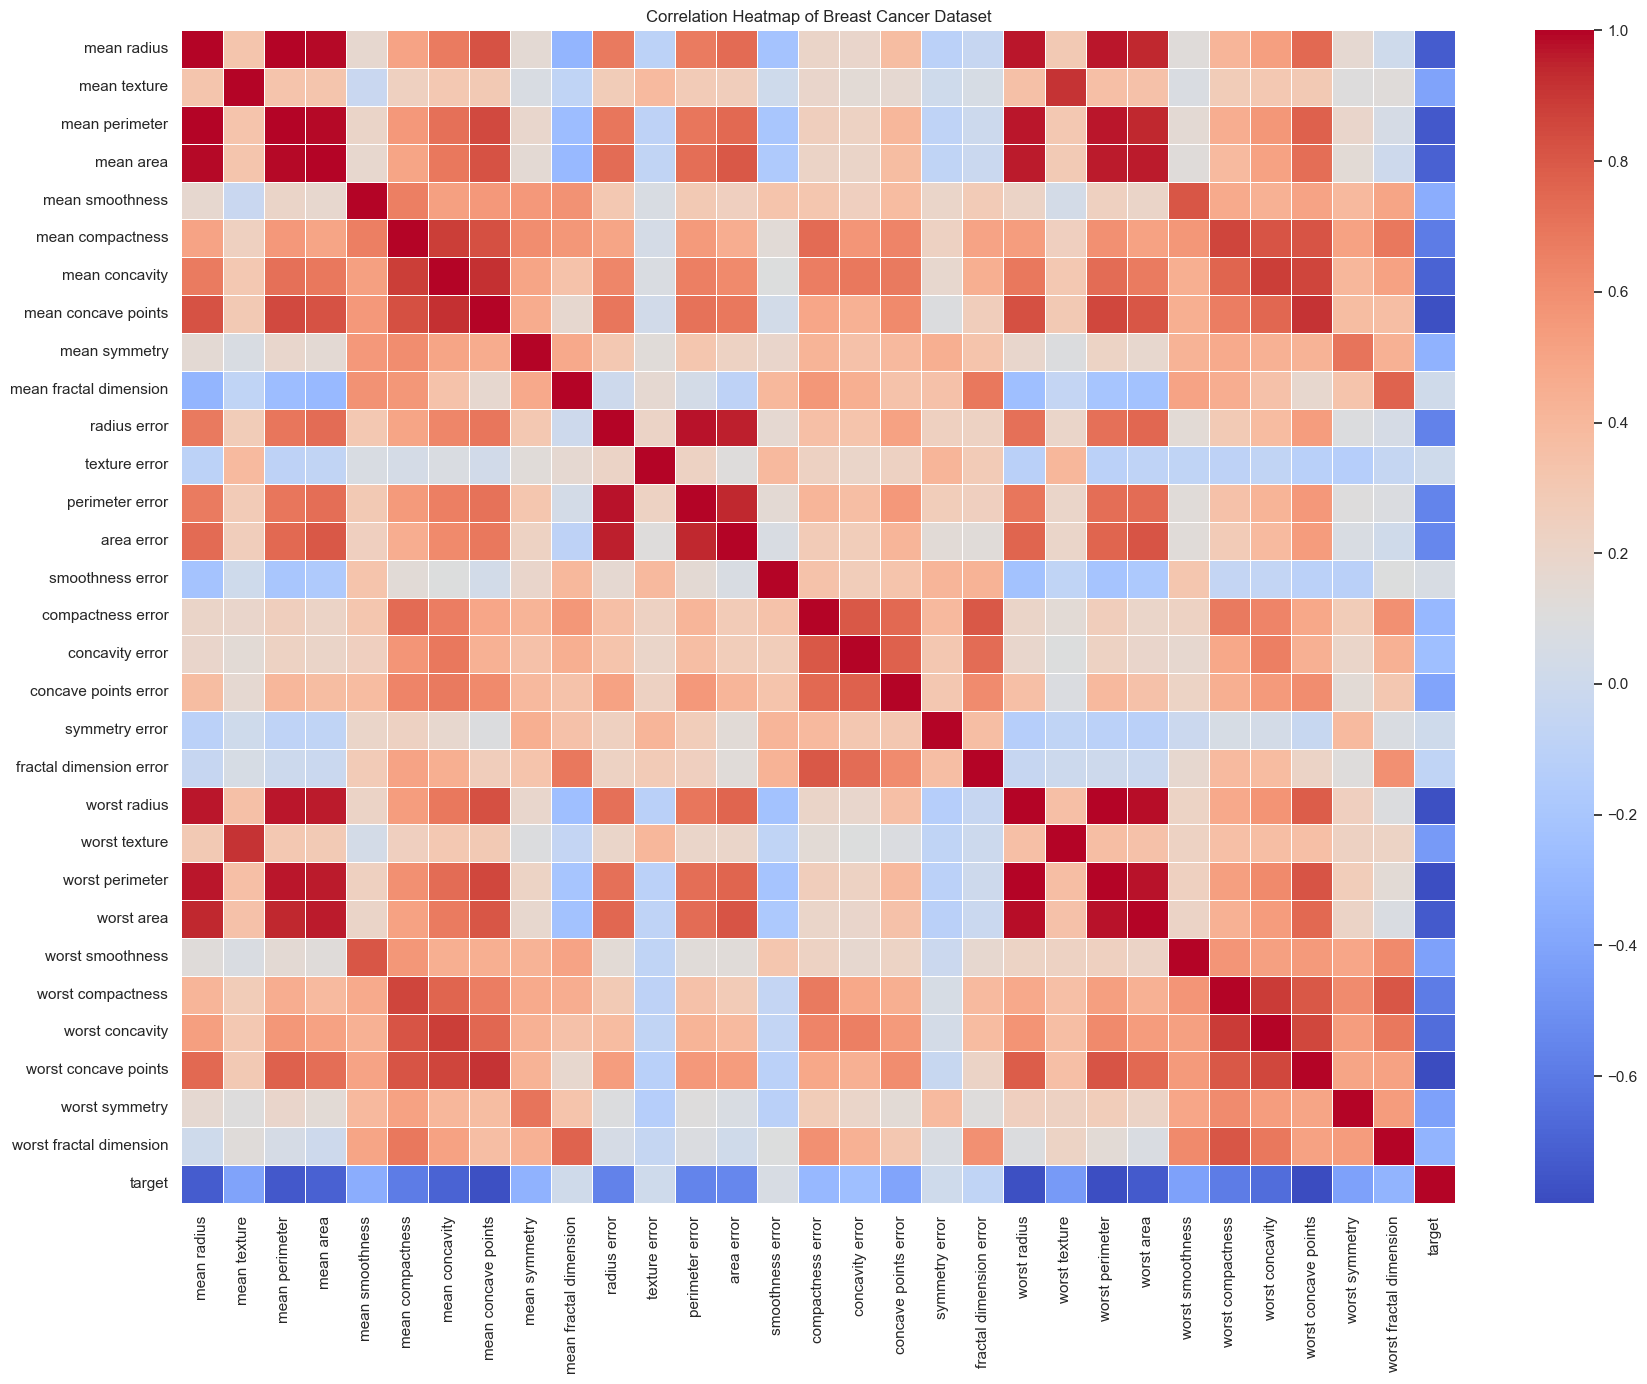

In [7]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df.drop("diagnosis_label", axis=1).corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Breast Cancer Dataset")
plt.tight_layout()
plt.show()

In [ ]:
## 6. Top Features Correlated with Diagnosis

This section identifies the features most strongly correlated with the diagnosis target. 
These features help explain which tumour measurements may be most useful for classification.

In [8]:
# ============================================================
# TOP FEATURES CORRELATED WITH TARGET
# ============================================================

target_correlation = correlation_matrix["target"].sort_values(ascending=False)
target_correlation

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

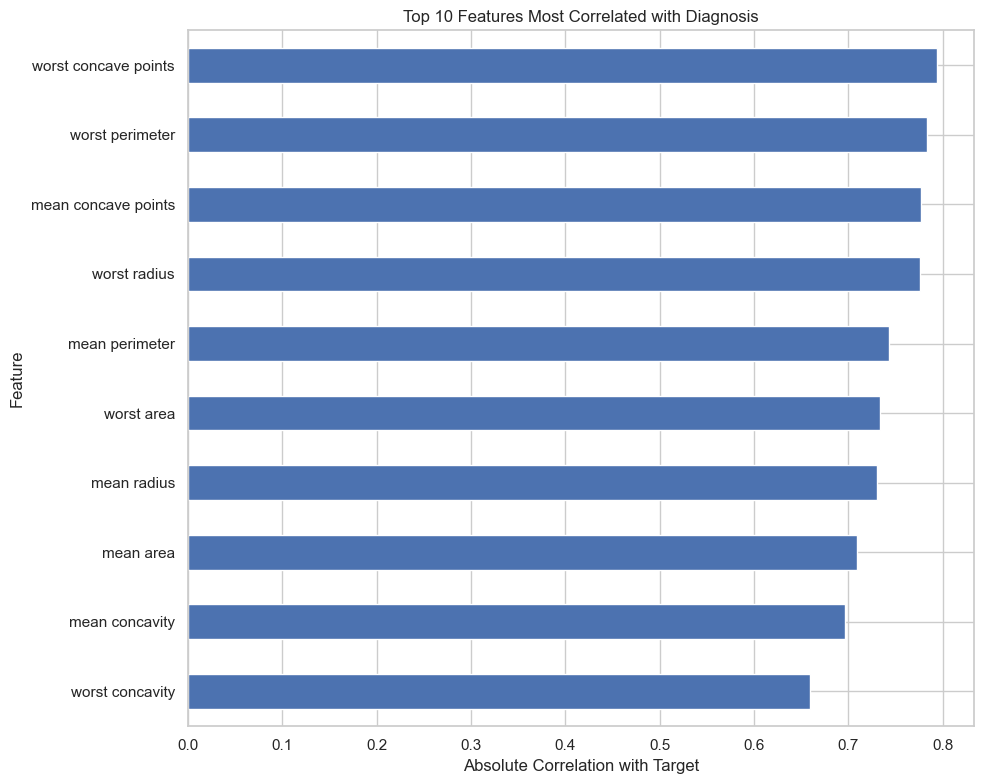

In [9]:
plt.figure(figsize=(10, 8))

target_correlation.drop("target").abs().sort_values(ascending=False).head(10).plot(
    kind="barh"
)

plt.title("Top 10 Features Most Correlated with Diagnosis")
plt.xlabel("Absolute Correlation with Target")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
## 7. Boxplot Analysis

Boxplots are used to compare selected tumour measurements across malignant and benign diagnoses. 
These visuals help identify whether the classes show visible separation.

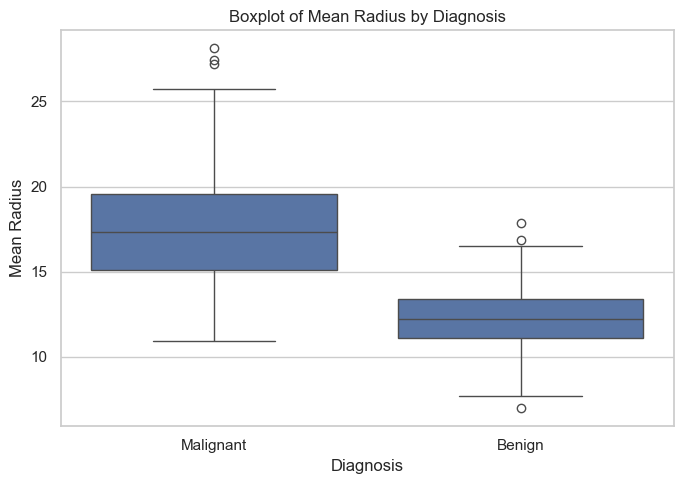

In [10]:
# ============================================================
# BOXPLOT: MEAN RADIUS
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="diagnosis_label",
    y="mean radius",
    data=df,
    order=["Malignant", "Benign"]
)

plt.title("Boxplot of Mean Radius by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Radius")
plt.tight_layout()
plt.show()

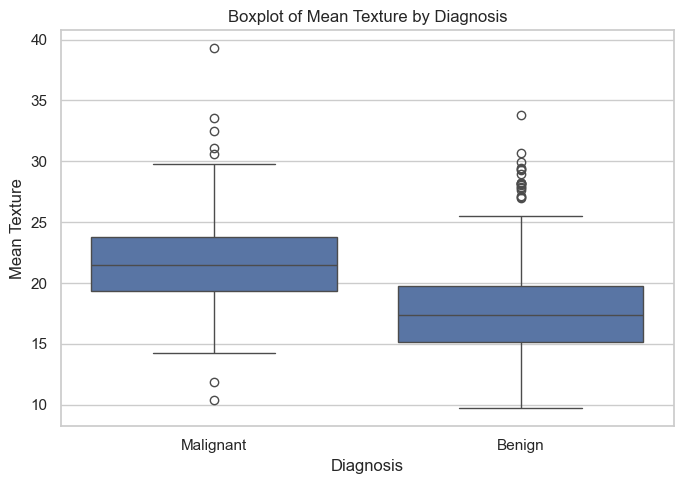

In [11]:
# ============================================================
# BOXPLOT: MEAN TEXTURE
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="diagnosis_label",
    y="mean texture",
    data=df,
    order=["Malignant", "Benign"]
)

plt.title("Boxplot of Mean Texture by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Texture")
plt.tight_layout()
plt.show()

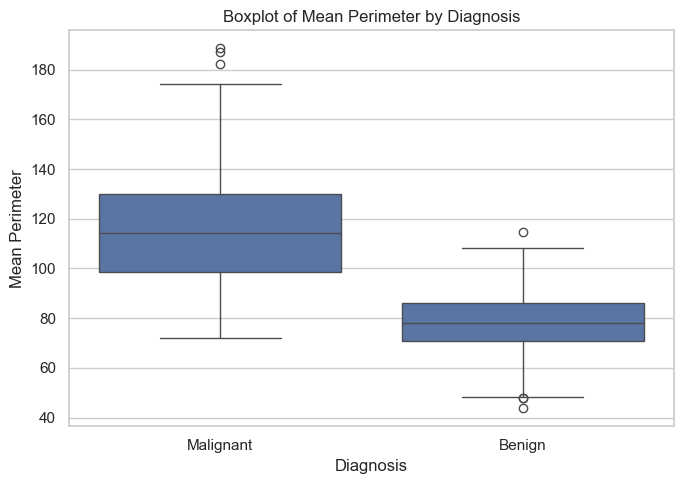

In [12]:
# ============================================================
# BOXPLOT: MEAN PERIMETER
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="diagnosis_label",
    y="mean perimeter",
    data=df,
    order=["Malignant", "Benign"]
)

plt.title("Boxplot of Mean Perimeter by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Perimeter")
plt.tight_layout()
plt.show()

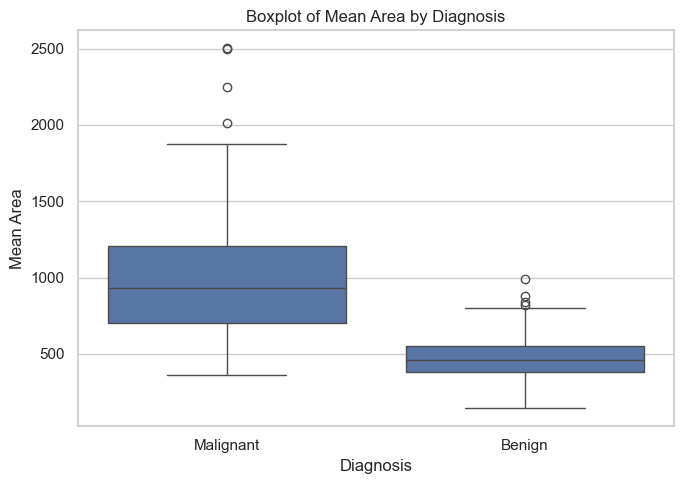

In [13]:
# ============================================================
# BOXPLOT: MEAN AREA
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="diagnosis_label",
    y="mean area",
    data=df,
    order=["Malignant", "Benign"]
)

plt.title("Boxplot of Mean Area by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Area")
plt.tight_layout()
plt.show()

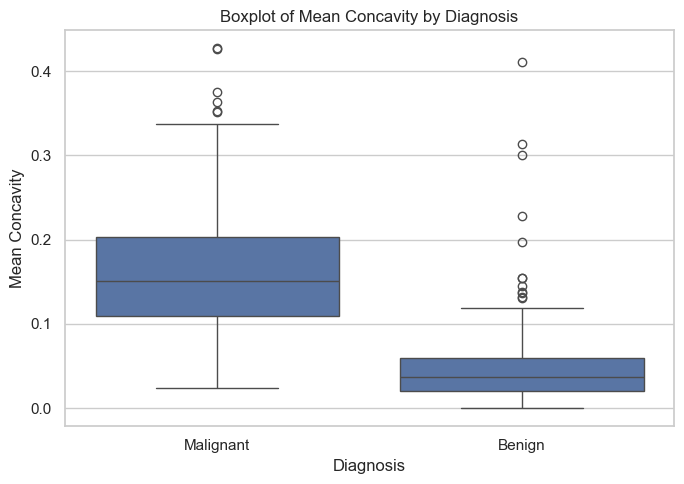

In [14]:
# ============================================================
# BOXPLOT: MEAN CONCAVITY
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    x="diagnosis_label",
    y="mean concavity",
    data=df,
    order=["Malignant", "Benign"]
)

plt.title("Boxplot of Mean Concavity by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Concavity")
plt.tight_layout()
plt.show()

In [ ]:
## 8. Feature and Target Preparation

The original dataset codes malignant as 0 and benign as 1.
For this project, malignant is recoded as 1 so that recall_score() evaluates malignant recall by default.
This is important because malignant false negatives are the most serious error in this healthcare context.

In [15]:
# ============================================================
# FEATURE AND TARGET SEPARATION
# ============================================================

X = df.drop(["target", "diagnosis_label"], axis=1)

# Recode target:
# Original dataset: 0 = Malignant, 1 = Benign
# New target: 1 = Malignant, 0 = Benign
y = df["target"].map({
    0: 1,
    1: 0
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nNew target value counts:")
print(y.value_counts())

Features shape: (569, 30)
Target shape: (569,)

New target value counts:
target
0    357
1    212
Name: count, dtype: int64


In [ ]:
## 9. Train-Test Split

The dataset is split into training and testing sets. 
The training set is used to train the models, while the test set is used to evaluate model performance on unseen data.

In [16]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (455, 30)
Testing feature shape: (114, 30)
Training target shape: (455,)
Testing target shape: (114,)


In [ ]:
## 10. Feature Scaling

Feature scaling is applied for Logistic Regression because the model can be affected by differences in feature magnitude.
Tree-based models such as Decision Trees and Random Forests do not require scaling in the same way.

In [17]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
## 11. Model Evaluation Function

A reusable function is created to evaluate each classification model using accuracy, precision, recall, F1-score and ROC-AUC. 
Since malignant has been recoded as 1, recall now measures the ability to correctly identify malignant cases.

In [18]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1),
        "Recall": recall_score(y_true, y_pred, pos_label=1),
        "F1 Score": f1_score(y_true, y_pred, pos_label=1)
    }
    
    if y_prob is not None:
        results["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    else:
        results["ROC-AUC"] = np.nan
    
    return results

In [ ]:
## 12. Model 1: Logistic Regression

Logistic Regression is trained as a baseline binary classification model.
It is useful because it is interpretable and provides a benchmark for comparison with more complex models.

In [20]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

log_model = LogisticRegression(max_iter=5000, random_state=42)

log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)
log_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    log_predictions,
    target_names=["Benign", "Malignant"]
))

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
## 13. Model 2: Decision Tree Classifier

The Decision Tree Classifier is trained as a non-linear comparison model.
Decision Trees are easy to interpret, but they can overfit if the tree becomes too complex.

In [21]:
# ============================================================
# MODEL 2: DECISION TREE CLASSIFIER
# ============================================================

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)
tree_probabilities = tree_model.predict_proba(X_test)[:, 1]

print("DECISION TREE CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    tree_predictions,
    target_names=["Benign", "Malignant"]
))

DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [ ]:
## 14. Model 3: Random Forest Classifier

The Random Forest model is trained as the primary ensemble model.
It combines multiple decision trees and can reduce the overfitting risk associated with a single decision tree.

In [22]:
# ============================================================
# MODEL 3: RANDOM FOREST CLASSIFIER
# ============================================================

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=["Benign", "Malignant"]
))

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
## 15. Model Comparison Table

The three models are compared using the same test dataset. 
This makes it easier to identify which model performs best across several classification metrics.

In [23]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

model_results = []

model_results.append(
    evaluate_model("Logistic Regression", y_test, log_predictions, log_probabilities)
)

model_results.append(
    evaluate_model("Decision Tree", y_test, tree_predictions, tree_probabilities)
)

model_results.append(
    evaluate_model("Random Forest", y_test, rf_predictions, rf_probabilities)
)

results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603
2,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890


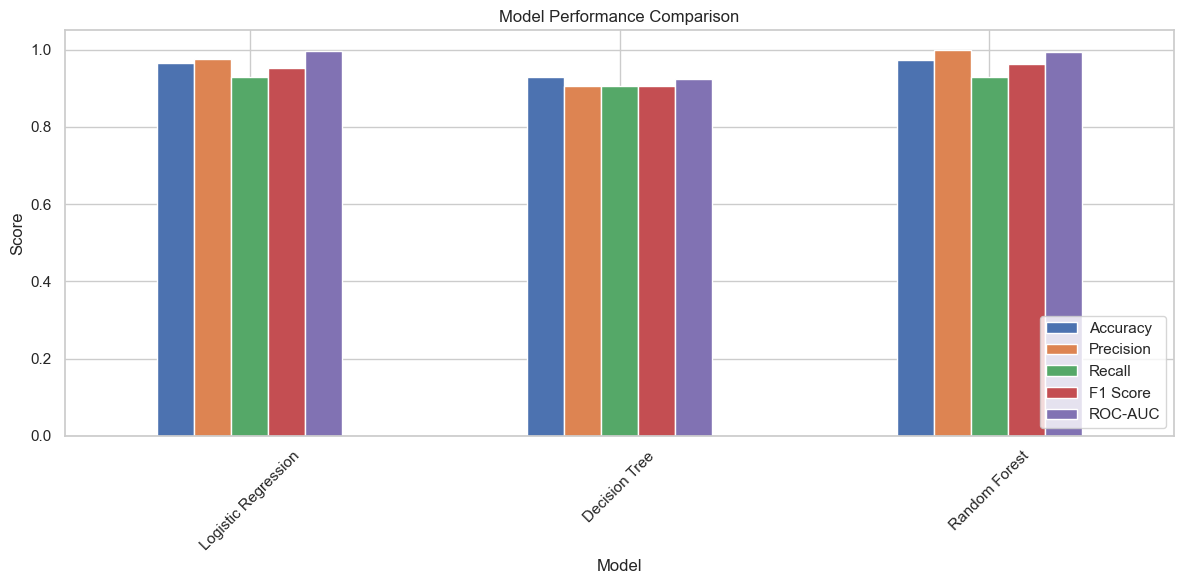

In [24]:
# ============================================================
# MODEL COMPARISON GRAPH
# ============================================================

results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

results_plot.plot(kind="bar", figsize=(12, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
## 16. Confusion Matrix for Random Forest

The confusion matrix shows the number of correct and incorrect predictions for benign and malignant cases.
False negatives are especially important because they represent malignant tumours incorrectly classified as benign.

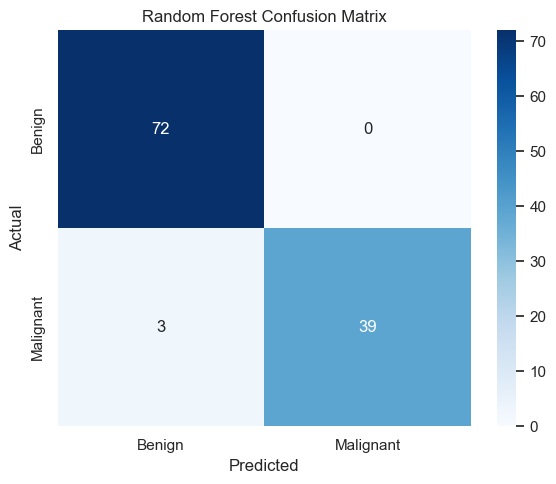

In [25]:
# ============================================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================================

rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
## 17. ROC Curves for All Models

ROC curves compare the ability of each model to distinguish between benign and malignant cases. 
A higher ROC-AUC score indicates stronger class separation.

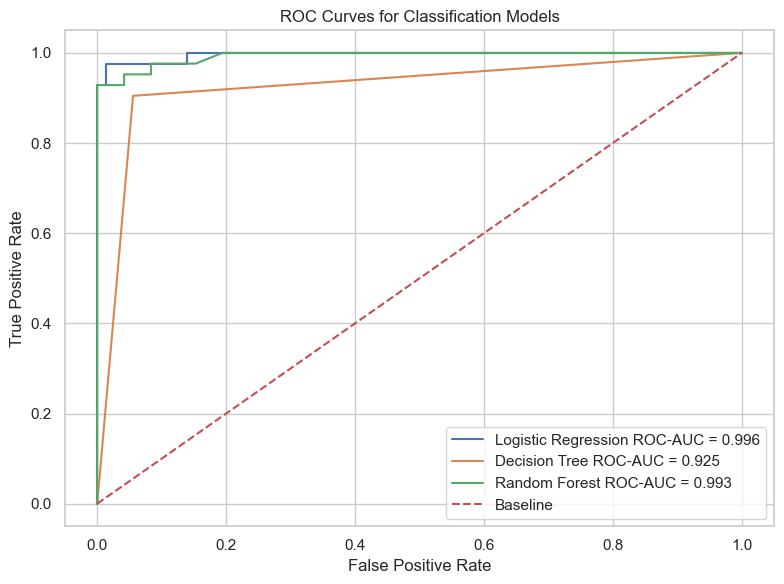

In [26]:
# ============================================================
# ROC CURVES FOR ALL CLASSIFICATION MODELS
# ============================================================

log_fpr, log_tpr, _ = roc_curve(y_test, log_probabilities)
log_auc = roc_auc_score(y_test, log_probabilities)

tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probabilities)
tree_auc = roc_auc_score(y_test, tree_probabilities)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)
rf_auc = roc_auc_score(y_test, rf_probabilities)

plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression ROC-AUC = {log_auc:.3f}")
plt.plot(tree_fpr, tree_tpr, label=f"Decision Tree ROC-AUC = {tree_auc:.3f}")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest ROC-AUC = {rf_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Baseline")

plt.title("ROC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## 18. Cross-Validation

Cross-validation evaluates model generalisation across multiple folds instead of relying on one train-test split only.
Recall is important here because malignant cases are the priority class.

In [27]:
# ============================================================
# CROSS VALIDATION FOR ALL MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest Baseline": RandomForestClassifier(random_state=42)
}

cv_results = []

for name, model in models.items():
    
    if name == "Logistic Regression":
        pipeline_model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipeline_model = model
    
    accuracy_scores = cross_val_score(
        pipeline_model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )
    
    recall_scores = cross_val_score(
        pipeline_model,
        X,
        y,
        cv=5,
        scoring="recall"
    )
    
    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": accuracy_scores.mean(),
        "CV Accuracy Std": accuracy_scores.std(),
        "CV Recall Mean": recall_scores.mean(),
        "CV Recall Std": recall_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,CV Accuracy Mean,CV Accuracy Std,CV Recall Mean,CV Recall Std
0,Logistic Regression,0.980686,0.006539,0.962237,0.024263
1,Decision Tree,0.917342,0.024195,0.910520,0.034195
2,Random Forest Baseline,0.956094,0.022839,0.929679,0.043895


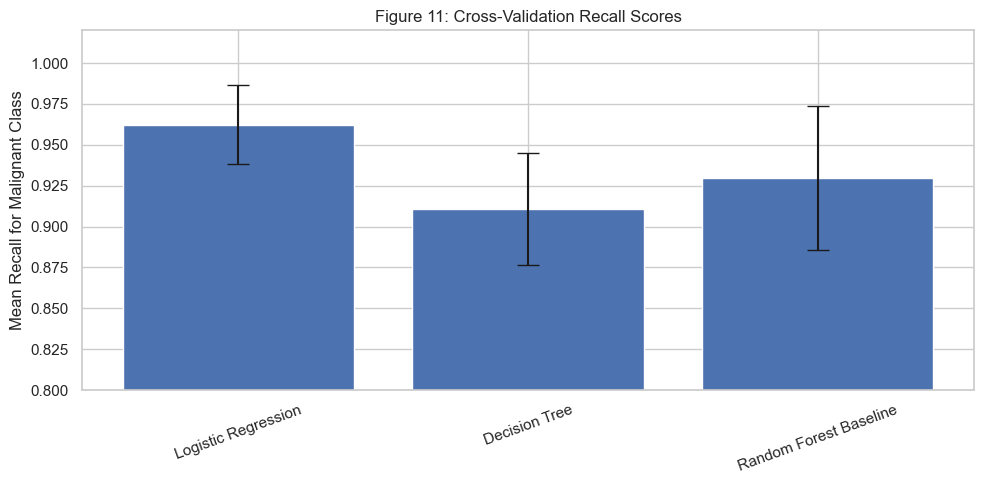

In [28]:
# ============================================================
# CROSS VALIDATION RECALL GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["CV Recall Mean"],
    yerr=cv_results_df["CV Recall Std"],
    capsize=8
)

plt.title("Figure 11: Cross-Validation Recall Scores")
plt.ylabel("Mean Recall for Malignant Class")
plt.xticks(rotation=20)
plt.ylim(0.80, 1.02)

plt.tight_layout()
plt.show()

In [ ]:
## 19. Parameter Testing for Random Forest

Several Random Forest parameter settings are tested to show how retraining affects model performance.
This supports model improvement and demonstrates that the model was not trained only once.

In [29]:
# ============================================================
# TEST DIFFERENT RANDOM FOREST PARAMETER SETTINGS
# ============================================================

parameter_tests = [
    {
        "label": "Baseline RF",
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "class_weight": None
    },
    {
        "label": "RF tuned A",
        "n_estimators": 200,
        "max_depth": 8,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "class_weight": "balanced"
    },
    {
        "label": "RF tuned B",
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
        "class_weight": "balanced"
    },
    {
        "label": "RF tuned C",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 10,
        "min_samples_leaf": 2,
        "class_weight": "balanced"
    }
]

test_results = []

for params in parameter_tests:
    
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        class_weight=params["class_weight"],
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    
    cv_recall_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="recall"
    )
    
    result = evaluate_model(
        params["label"],
        y_test,
        predictions,
        probabilities
    )
    
    result["CV Recall Mean"] = cv_recall_scores.mean()
    result["CV Recall Std"] = cv_recall_scores.std()
    
    test_results.append(result)

parameter_results_df = pd.DataFrame(test_results)
parameter_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Recall Mean,CV Recall Std
0,Baseline RF,0.973684,1.0,0.928571,0.962963,0.992890,0.929679,0.043895
1,RF tuned A,0.973684,1.0,0.928571,0.962963,0.997685,0.934441,0.044799
2,RF tuned B,0.973684,1.0,0.928571,0.962963,0.997024,0.948505,0.037101
3,RF tuned C,0.973684,1.0,0.928571,0.962963,0.996032,0.948505,0.037101


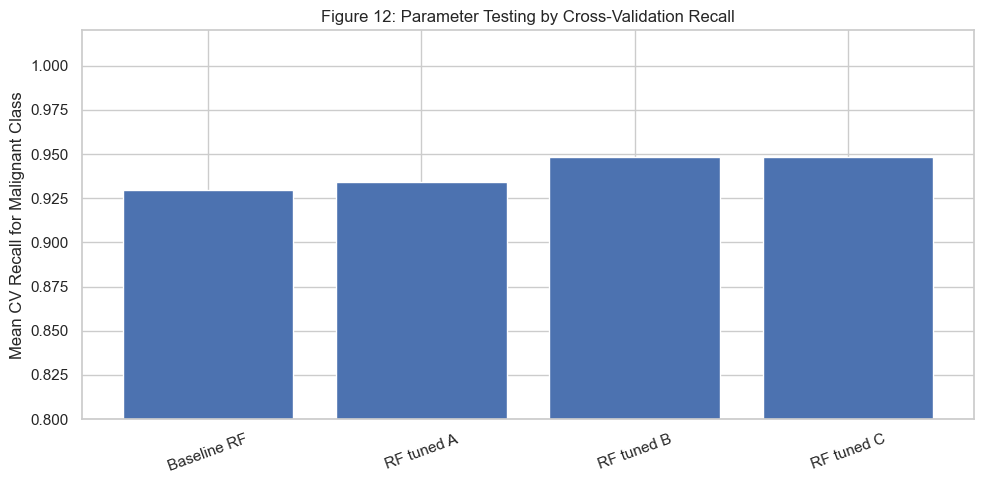

In [30]:
# ============================================================
# PARAMETER TESTING VISUALISATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    parameter_results_df["Model"],
    parameter_results_df["CV Recall Mean"]
)

plt.title("Figure 12: Parameter Testing by Cross-Validation Recall")
plt.ylabel("Mean CV Recall for Malignant Class")
plt.xticks(rotation=20)
plt.ylim(0.80, 1.02)

plt.tight_layout()
plt.show()

In [ ]:
## 20. Grid Search for Model Improvement

GridSearchCV is used to identify the best Random Forest parameter combination. 
The scoring metric is recall because the objective is to improve identification of malignant cases.

In [31]:
# ============================================================
# GRID SEARCH FOR MODEL IMPROVEMENT
# ============================================================

parameter_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 8, 10],
    "min_samples_split": [2, 4, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parameter_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation recall score:")
print(grid_search.best_score_)

Best parameters:
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation recall score:
0.9470588235294117


In [ ]:
## 21. Improved Random Forest Model

The best model from GridSearchCV is used as the improved model. Its performance is compared with the original Random Forest model.

In [32]:
# ============================================================
# RETRAIN IMPROVED RANDOM FOREST MODEL
# ============================================================

improved_rf_model = grid_search.best_estimator_

improved_predictions = improved_rf_model.predict(X_test)
improved_probabilities = improved_rf_model.predict_proba(X_test)[:, 1]

print("IMPROVED RANDOM FOREST CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    improved_predictions,
    target_names=["Benign", "Malignant"]
))

IMPROVED RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [33]:
# ============================================================
# ORIGINAL RANDOM FOREST VS IMPROVED RANDOM FOREST
# ============================================================

improvement_results = []

improvement_results.append(
    evaluate_model("Original Random Forest", y_test, rf_predictions, rf_probabilities)
)

improvement_results.append(
    evaluate_model("Improved Random Forest", y_test, improved_predictions, improved_probabilities)
)

improvement_df = pd.DataFrame(improvement_results)
improvement_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Original Random Forest,0.973684,1.0,0.928571,0.962963,0.99289
1,Improved Random Forest,0.973684,1.0,0.928571,0.962963,0.99289


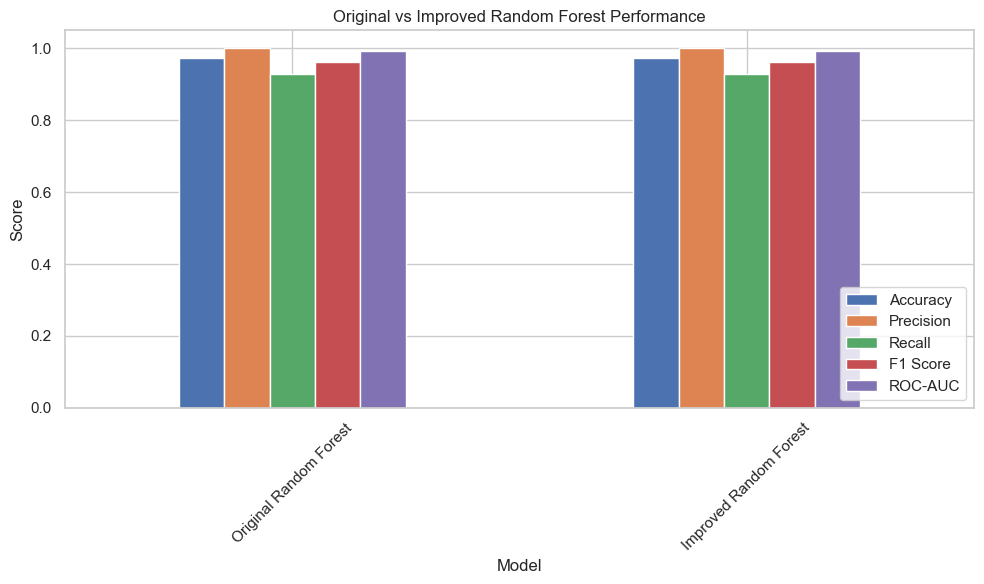

In [34]:
# ============================================================
# VISUALISE MODEL IMPROVEMENT
# ============================================================

improvement_plot = improvement_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

improvement_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Original vs Improved Random Forest Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
## 22. Improved Model Confusion Matrix

The improved model confusion matrix is used to inspect the number of false positives and false negatives after retraining.

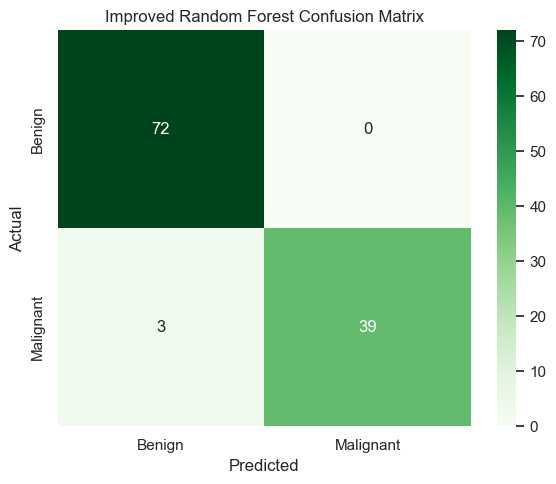

In [35]:
# ============================================================
# IMPROVED RANDOM FOREST CONFUSION MATRIX
# ============================================================

improved_cm = confusion_matrix(y_test, improved_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    improved_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Improved Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
## 23. Feature Importance

Feature importance from the improved Random Forest model is used to identify 
which tumour measurements contributed most strongly to the classification process.

In [36]:
# ============================================================
# FEATURE IMPORTANCE TABLE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": improved_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.151412
27,worst concave points,0.126497
20,worst radius,0.093475
22,worst perimeter,0.083642
7,mean concave points,0.081082
2,mean perimeter,0.077126
0,mean radius,0.061990
6,mean concavity,0.050818
3,mean area,0.045916
26,worst concavity,0.030022


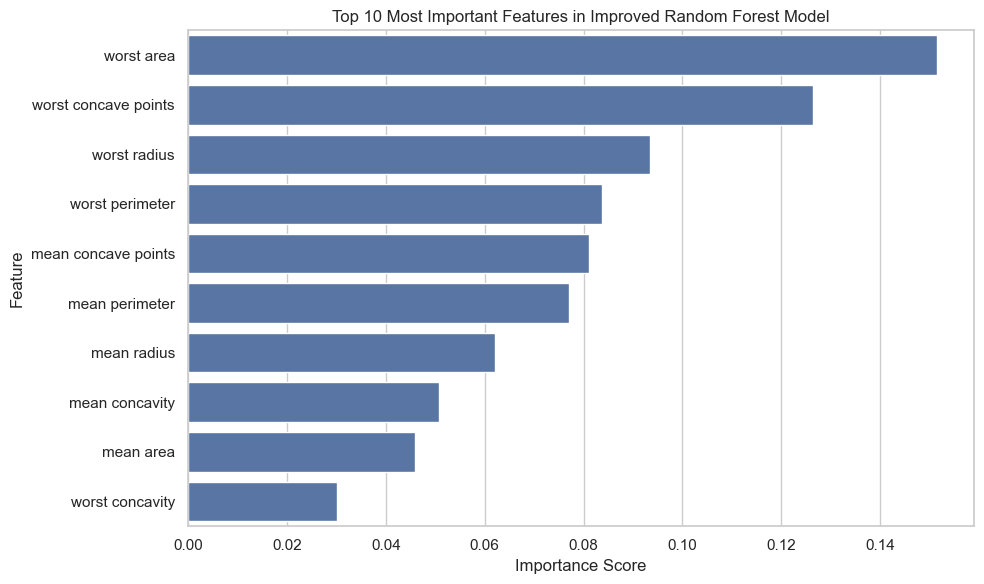

In [37]:
# ============================================================
# FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Most Important Features in Improved Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
## 24. Pipeline Implementation

A pipeline is created to combine preprocessing and modelling into one workflow. 
This is useful because it makes the machine learning process cleaner and more reproducible.

In [38]:
# ============================================================
# PIPELINE IMPLEMENTATION
# ============================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

pipeline_predictions = pipeline.predict(X_test)
pipeline_probabilities = pipeline.predict_proba(X_test)[:, 1]

pipeline_results = evaluate_model(
    "Pipeline Random Forest",
    y_test,
    pipeline_predictions,
    pipeline_probabilities
)

pipeline_results

{'Model': 'Pipeline Random Forest',
 'Accuracy': 0.9736842105263158,
 'Precision': 1.0,
 'Recall': 0.9285714285714286,
 'F1 Score': 0.9629629629629629,
 'ROC-AUC': 0.9928902116402116}

In [ ]:
## 25. Final Model Summary

The final table summarises all major models tested in this analysis.
This helps compare the baseline, improved and pipeline-based models using the same evaluation metrics.

In [39]:
# ============================================================
# FINAL MODEL SUMMARY
# ============================================================

final_summary = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, log_predictions, log_probabilities),
    evaluate_model("Decision Tree", y_test, tree_predictions, tree_probabilities),
    evaluate_model("Random Forest", y_test, rf_predictions, rf_probabilities),
    evaluate_model("Improved Random Forest", y_test, improved_predictions, improved_probabilities),
    evaluate_model("Pipeline Random Forest", y_test, pipeline_predictions, pipeline_probabilities)
])

final_summary

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603
2,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890
3,Improved Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890
4,Pipeline Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890


In [ ]:
## 26. Save Results

The model results and feature importance tables are saved as CSV files so that the values can be used consistently in the final report.

In [40]:
# ============================================================
# SAVE RESULTS TO CSV
# ============================================================

final_summary.to_csv("pdan8411_part2_model_results.csv", index=False)
feature_importance.to_csv("pdan8411_part2_feature_importance.csv", index=False)
cv_results_df.to_csv("pdan8411_part2_cross_validation_results.csv", index=False)
parameter_results_df.to_csv("pdan8411_part2_parameter_testing_results.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
